<a href="https://colab.research.google.com/github/nathanellsley-del/Hist1354_Digital_Methods_Milestone_3/blob/main/Milestone_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ****Milestone 3: Looking at the Relationship Between A State's Percentage of People Who had a Bachelor's Degree or Higher and the Median Personal Income By Examining the Vietnam Veteran Population From Each State****

**Importing the Librariers**

The first step in any code is to import all the libraries that I think we're going to need for the projet. I began by importing the generic packages that process files and generate charts and graphs.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print('Libraries have successfully been imported')

Libraries have successfully been imported


**Uploading The Data And Creating The Dataframe**

I uploaded the .csv file into Google Colab and copied its path into the code. The data was formed such that the titles for all the variables are written on the second line of cells in the .csv so in order for the program to understand the title I was refering too, I had to direct the code to look for the headers in line 1.

The .csv file likewise did not have a title for the column that listed each state, so I renamed the "Unnamed: 0" column to "State" for future reference in the code. After doing that, I deleted all the columns not related to the three variables I was tracking: the state the data is being reported from, median personal income of the veterans, and the percentage of veterans who held a Bachelor's Degree or higher.

To ensure the code executed properly, I had the code print that it worked.

In [12]:
file_path = ('/content/HIST_1534_Dataset_Vietnam_Veterans_by_State.csv')
df = pd.read_csv(file_path, header=1)

df = df.rename(columns={'Unnamed: 0': 'State'})
df = df[["State", "Median Personal Income", "Bachelor's Degree or Higher"]]

print('worked')

worked


**Cleaning The Dataframe**

Next I asked the program to tell me how many datapoints where missing in each of the columns. Then I went through the datapoints and cleaned all the data that was incomplete, such as changing some formats so that the program would be able to read it.

After doing that for both of the columns for the datapoints I was observing, I created the new variable "clean_df" which encompassed all the cleaned data.

In [13]:
missing_data = df.isnull().sum()
print(missing_data)

filtered_out_rows = df.dropna(subset=["Bachelor's Degree or Higher"])
len(df)

clean_df = filtered_out_rows.copy()

clean_df["Median Personal Income"] = clean_df["Median Personal Income"].str.replace(',', '', regex=False)
clean_df["Median Personal Income"] = pd.to_numeric(clean_df["Median Personal Income"], errors='coerce')

clean_df["Bachelor's Degree or Higher"] = clean_df["Bachelor's Degree or Higher"].replace('▪', np.nan, regex=False)
clean_df["Bachelor's Degree or Higher"] = pd.to_numeric(clean_df["Bachelor's Degree or Higher"], errors='coerce')

clean_df = clean_df.dropna(subset=["Median Personal Income", "Bachelor's Degree or Higher"])

correlation = clean_df["Median Personal Income"].corr(clean_df["Bachelor's Degree or Higher"])

print(f'The correlation between Median Personal Income and Bachelor\'s Degree or Higher is: {correlation:.2f}')
print('done')

State                          2
Median Personal Income         8
Bachelor's Degree or Higher    8
dtype: int64
The correlation between Median Personal Income and Bachelor's Degree or Higher is: 0.54
done


**My First Visualization**

I decided to use the package matplotlib.pyplot for my first attempt to create a visualization because it was what I was used to using.

To label each data point, I implemented an index-based for loop that iterates through each row of the dataset. Within this loop, and referencing the sytanx recommendations of generate AI, I used positional indexing (.iloc) to access the values for each state and placed a text label directly on the plot at the corresponding coordinates.

After plotting the data, I added a title and labeled both axes to provide context for the viewer.

When the initial output appeared cluttered and difficult to read due to overlapping labels, I adjusted the figure size and font size from 10 to 20 in an attempt to improve clarity and overall presentation, but I still wasn't happy with the way the data was presented.

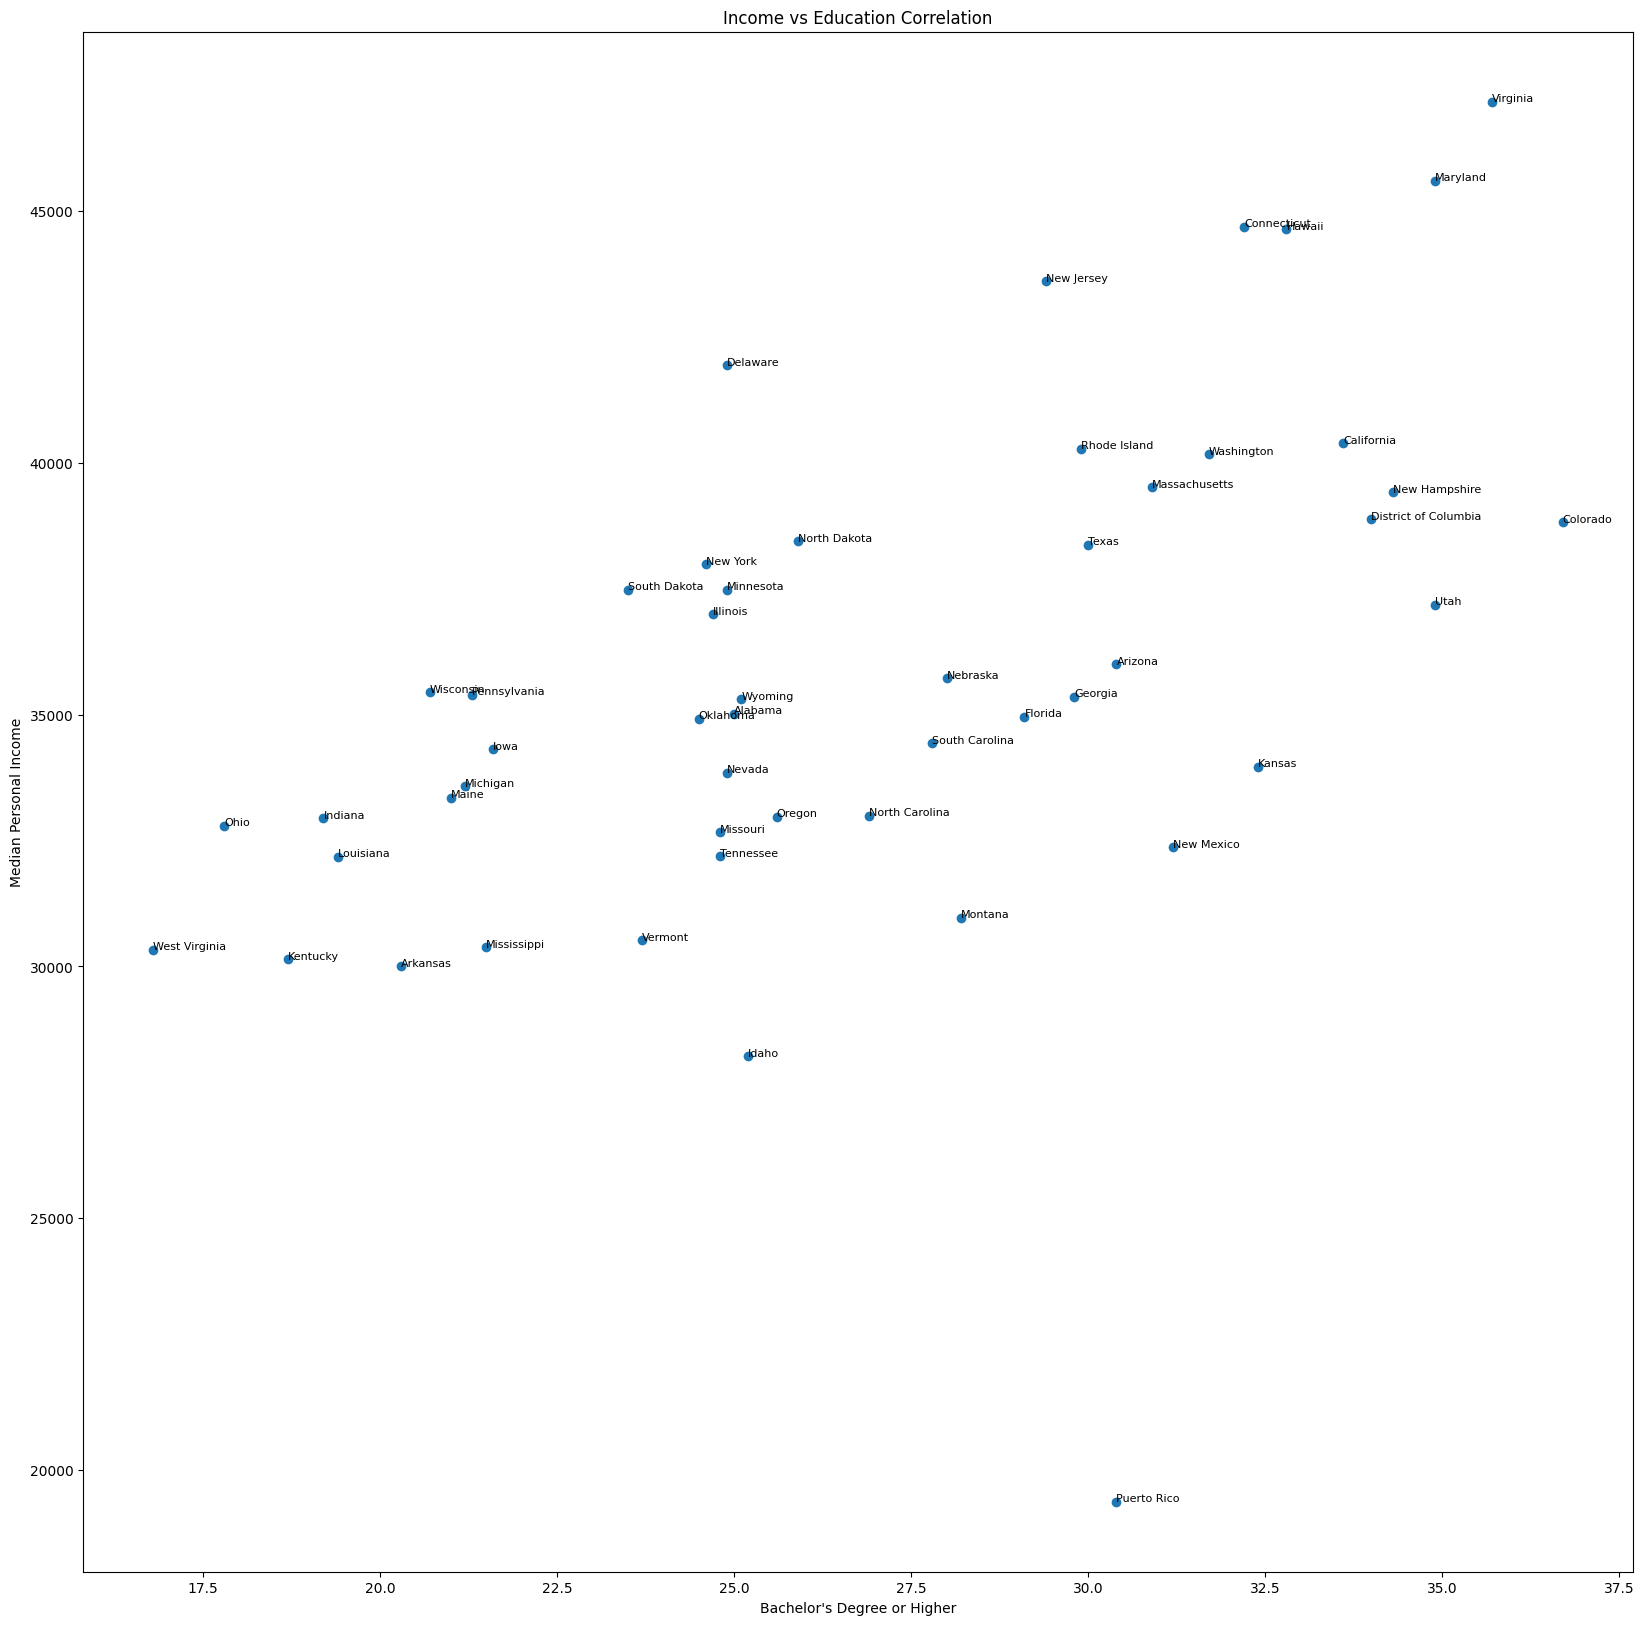

In [14]:
plt.figure(figsize=(20,20))
plt.scatter(clean_df["Bachelor's Degree or Higher"], clean_df["Median Personal Income"])
for state in range(len(clean_df)):
    plt.text(
        clean_df["Bachelor's Degree or Higher"].iloc[state],
        clean_df["Median Personal Income"].iloc[state],
        clean_df["State"].iloc[state],
        fontsize=8
    )
plt.xlabel("Bachelor's Degree or Higher")
plt.ylabel("Median Personal Income")
plt.title("Income vs Education Correlation")

plt.show()


**My Second Visualization**

After realizing the limitations of matplotlib.pyplot, I decided to source a new package to better display my data. Using the reccomendation of generative AI, I adopted plotly.express as my data visualization tool.

First I imported plotly.express. Next I used the guidance of generative AI to give me the syntax to direct the package to create a scatterplot using the cleaned dataframe, telling the program which variable should correspond to each axis.

Next I directed the program how I wanted to display the data, including how the hover function would work.

Lastly I the costumized layout by deciding the height, width, and axes titles.

When I was done, I had the program show me the visualzation.

In [15]:
import plotly.express as px

fig = px.scatter(
    clean_df,
    x="Bachelor's Degree or Higher",
    y="Median Personal Income",
    text = "State",
    title="Median Personal Income vs Education by State"
)

fig.update_traces(marker=dict(size=10, color='blue'),
                  selector=dict(mode='markers+text'))

fig.update_layout(
    width=1000,
    height=500,
    hovermode="closest",
    xaxis_title="Percent of Service Members with Bachelor's Degree or Higher",
    yaxis_title="Median Personal Income in USD"
)

fig.show()